<a href="https://colab.research.google.com/github/smitp2705/maths-pr4/blob/main/Maths_pr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, zscore
from scipy.stats import boxcox
from statsmodels.graphics.gofplots import qqplot

sns.set_style("whitegrid")


In [4]:
df = pd.read_csv("/content/spread_locator_dataset - spread_locator_dataset.csv.csv")
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB


In [6]:
df.describe(include='all')

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
count,220,220,220.000000,220,220.000000,220,220
unique,220,217,NaN,31,NaN,4,2
top,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST7912,NaN,2023-01-18,NaN,West,Fail
freq,1,2,NaN,12,NaN,66,122
mean,NaN,NaN,3365.192409,NaN,2.854545,NaN,NaN
std,NaN,NaN,1985.705409,NaN,1.797189,NaN,NaN
min,NaN,NaN,804.420000,NaN,0.000000,NaN,NaN
25%,NaN,NaN,2124.205000,NaN,1.750000,NaN,NaN
50%,NaN,NaN,3077.715000,NaN,3.000000,NaN,NaN
75%,NaN,NaN,3950.737500,NaN,4.000000,NaN,NaN


In [7]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
transaction_amount,0
transaction_date,0
transaction_count,0
region,0
transaction_status,0


Probability of Success: 0.44545454545454544


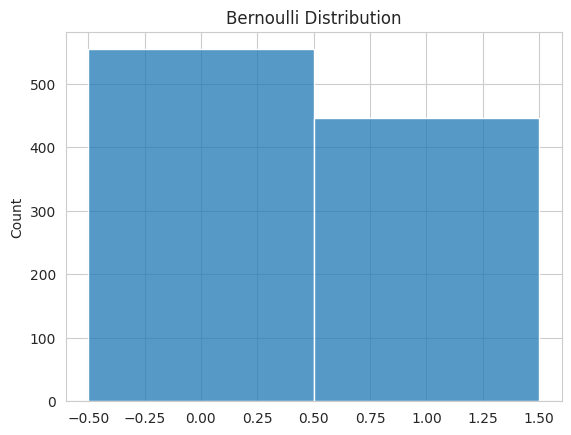

In [8]:
if 'transaction_status' in df.columns:
    df['success_binary'] = df['transaction_status'].apply(lambda x: 1 if str(x).lower() == 'success' else 0)

    p = df['success_binary'].mean()
    print("Probability of Success:", p)

    bernoulli_sample = bernoulli.rvs(p, size=1000)

    sns.histplot(bernoulli_sample, discrete=True)
    plt.title("Bernoulli Distribution")
    plt.show()


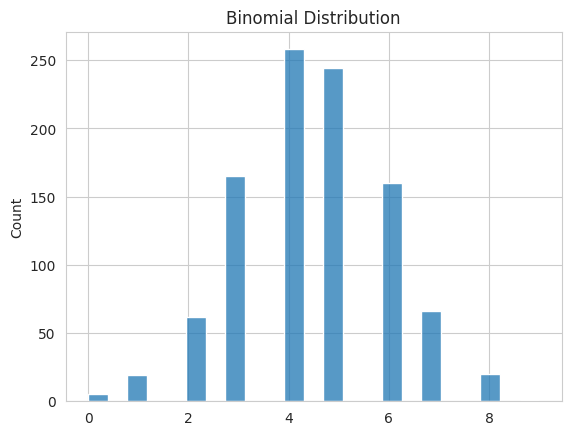

In [9]:
if 'transaction_count' in df.columns:
    n = int(df['transaction_count'].max())
    p = 0.5

    binomial_sample = binom.rvs(n=n, p=p, size=1000)

    sns.histplot(binomial_sample, kde=False)
    plt.title("Binomial Distribution")
    plt.show()

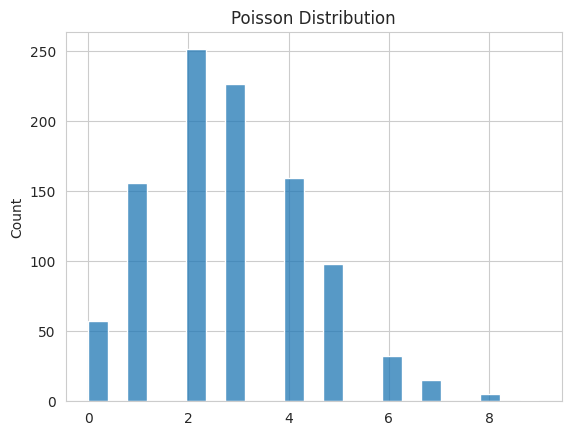

In [10]:
if 'transaction_count' in df.columns:
    lam = df['transaction_count'].mean()

    poisson_sample = poisson.rvs(mu=lam, size=1000)

    sns.histplot(poisson_sample, kde=False)
    plt.title("Poisson Distribution")
    plt.show()

Log-normal parameters: 0.4749178350151927 0 2983.1591334067753


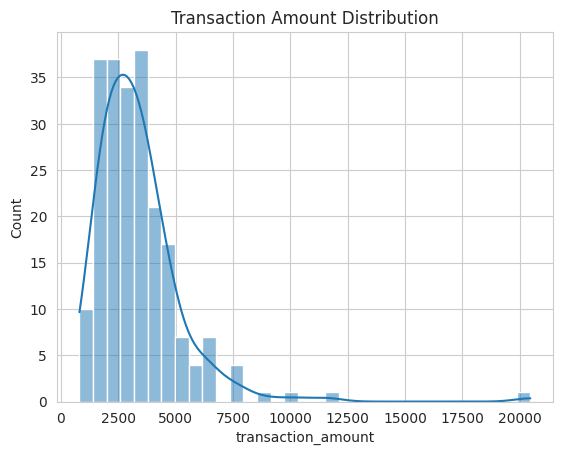

Power Law Parameters: (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


In [11]:
if 'transaction_amount' in df.columns:
    amount = df['transaction_amount'].dropna()

    # Log-normal fit
    shape, loc, scale = lognorm.fit(amount, floc=0)
    print("Log-normal parameters:", shape, loc, scale)

    sns.histplot(amount, kde=True)
    plt.title("Transaction Amount Distribution")
    plt.show()

    # Power law fit
    power_params = powerlaw.fit(amount)
    print("Power Law Parameters:", power_params)

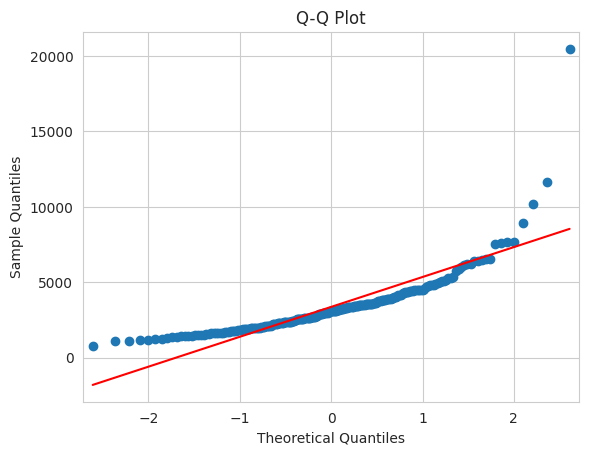

In [12]:
if 'transaction_amount' in df.columns:
    qqplot(df['transaction_amount'].dropna(), line='s')
    plt.title("Q-Q Plot")
    plt.show()

Lambda Value: -0.18083390743966327


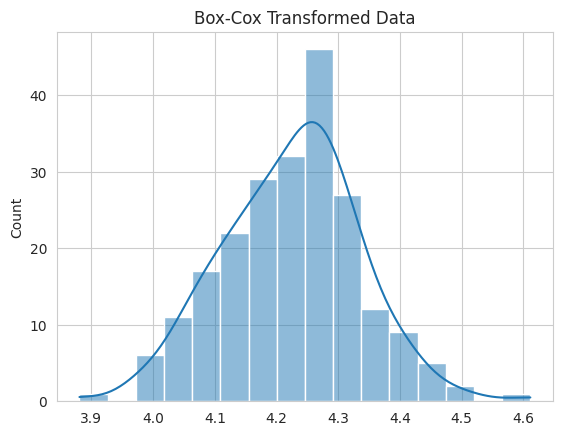

In [13]:
if 'transaction_amount' in df.columns:
    amount = df['transaction_amount'].dropna()

    # Ensure positive values
    amount = amount[amount > 0]

    transformed_data, lambda_value = boxcox(amount)

    print("Lambda Value:", lambda_value)

    sns.histplot(transformed_data, kde=True)
    plt.title("Box-Cox Transformed Data")
    plt.show()


In [14]:
if 'transaction_amount' in df.columns:
    df['z_score'] = zscore(df['transaction_amount'].fillna(df['transaction_amount'].mean()))

    df[['transaction_amount', 'z_score']].head()

In [15]:
if 'transaction_amount' in df.columns:
    mean = df['transaction_amount'].mean()
    std = df['transaction_amount'].std()

    probability = 1 - stats.norm.cdf(5000, loc=mean, scale=std)

    print("Probability of transaction amount exceeding 5000:", probability)

Probability of transaction amount exceeding 5000: 0.20517209567554384


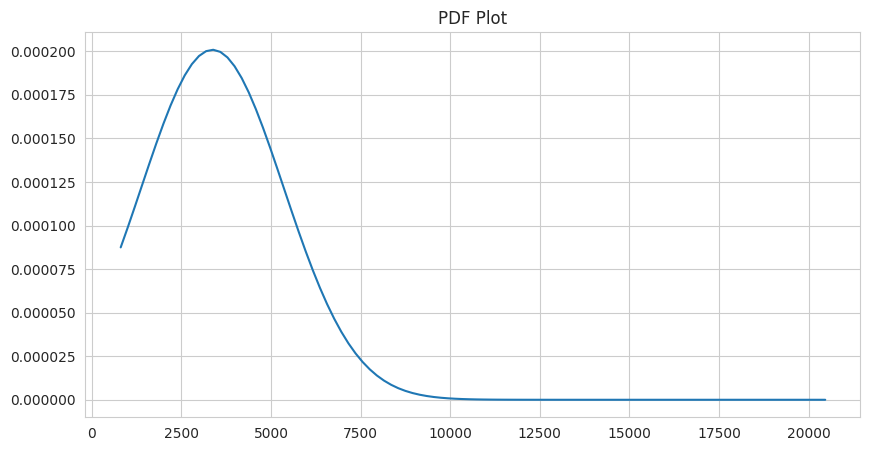

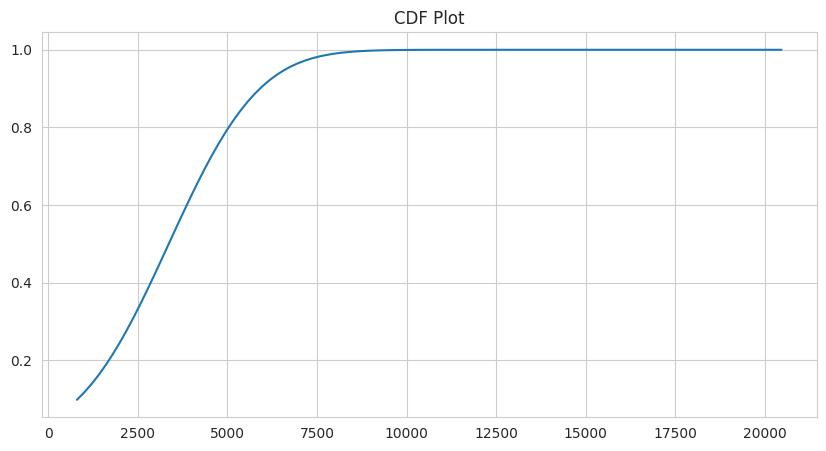

In [16]:
if 'transaction_amount' in df.columns:
    data = df['transaction_amount'].dropna()

    x = np.linspace(data.min(), data.max(), 100)

    mean = data.mean()
    std = data.std()

    pdf = stats.norm.pdf(x, mean, std)
    cdf = stats.norm.cdf(x, mean, std)

    plt.figure(figsize=(10,5))
    plt.plot(x, pdf)
    plt.title("PDF Plot")
    plt.show()

    plt.figure(figsize=(10,5))
    plt.plot(x, cdf)
    plt.title("CDF Plot")
    plt.show()
